In [72]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from aquarel import load_theme
import seaborn as sns
import scipy.stats as stats

FE_DF_PATH = Path("../data/processed/paysim_feature_engineered.parquet")
fe_df = pd.read_parquet(FE_DF_PATH)

In [73]:
# look at the dataframe
fe_df.head()

,step,type,amount,oldBalanceOrig,newBalanceOrig,oldBalanceDest,newBalanceDest,isFlaggedFraud,senderBalanceError,receiverBalanceError,netChangeOrig,netChangeDest,isLargeTransaction,day,hour,dayOfWeek,amountToBalanceRatio,isFraud
0,1,PAYMENT,9839.639648,170136.0,160296.359375,0.0,0.0,0,0,1,-9839.640625,0.0,0,0,1,0,0.057834,0
1,1,PAYMENT,1864.280029,21249.0,19384.720703,0.0,0.0,0,0,1,-1864.279297,0.0,0,0,1,0,0.087731,0
2,1,TRANSFER,181.000000,181.0,0.000000,0.0,0.0,0,0,1,-181.000000,0.0,0,0,1,0,0.994505,1
3,1,CASH OUT,181.000000,181.0,0.000000,21182.0,0.0,0,0,1,-181.000000,-21182.0,0,0,1,0,0.994505,1
4,1,PAYMENT,11668.139648,41554.0,29885.859375,0.0,0.0,0,0,1,-11668.140625,0.0,0,0,1,0,0.280788,0


In [74]:
# shape of dataframe
fe_df.shape

(6362620, 18)

In [75]:
# df info
fe_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 18 columns):
 #   Column                Dtype   
---  ------                -----   
 0   step                  int64   
 1   type                  category
 2   amount                float32 
 3   oldBalanceOrig        float32 
 4   newBalanceOrig        float32 
 5   oldBalanceDest        float32 
 6   newBalanceDest        float32 
 7   isFlaggedFraud        int8    
 8   senderBalanceError    int8    
 9   receiverBalanceError  int8    
 10  netChangeOrig         float32 
 11  netChangeDest         float32 
 12  isLargeTransaction    int8    
 13  day                   int8    
 14  hour                  int8    
 15  dayOfWeek             int8    
 16  amountToBalanceRatio  float32 
 17  isFraud               int8    
dtypes: category(1), float32(8), int64(1), int8(8)
memory usage: 297.3 MB


In [76]:
# check any duplicate values
fe_df.duplicated().sum()

np.int64(543)

## Exploratory Data Analysis

In [77]:
fe_df.describe(include="number").round(2)

,step,amount,oldBalanceOrig,newBalanceOrig,oldBalanceDest,newBalanceDest,isFlaggedFraud,senderBalanceError,receiverBalanceError,netChangeOrig,netChangeDest,isLargeTransaction,day,hour,dayOfWeek,amountToBalanceRatio,isFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.0,6362620.00,6362620.00,6362620.00,6.362620e+06,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00
mean,243.40,179861.89,833883.12,855113.62,1.100702e+06,1.224996e+06,0.0,0.85,0.86,21230.56,1.242947e+05,0.01,9.50,15.32,2.48,70674.48,0.00
std,142.33,603858.25,2888242.75,2924048.50,3.399180e+06,3.674129e+06,0.0,0.36,0.34,146643.28,8.129391e+05,0.10,5.92,4.32,2.17,508424.28,0.04
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.0,0.00,0.00,-10000002.00,-1.306083e+07,0.00,0.00,0.00,0.00,0.00,0.00
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.0,1.00,1.00,-10150.44,0.000000e+00,0.00,6.00,12.00,1.00,0.23,0.00
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146615e+05,0.0,1.00,1.00,0.00,0.000000e+00,0.00,9.00,16.00,2.00,6.45,0.00
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.0,1.00,1.00,0.00,1.491054e+05,0.00,13.00,19.00,5.00,12287.76,0.00
max,743.00,92445520.00,59585040.00,49585040.00,3.560159e+08,3.561793e+08,1.0,1.00,1.00,1915268.00,1.056878e+08,1.00,30.00,23.00,6.00,92445520.00,1.00


### Target Variable Analysis

In [78]:
# set theme and matplotlib parameters
theme = load_theme("minimal_light")
theme.apply()

plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.labelsize": 13,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.family": "monospace",
    "xtick.labelcolor": "black",
    "ytick.labelcolor": "black",
})

Is the target (isFraud) imbalanced?

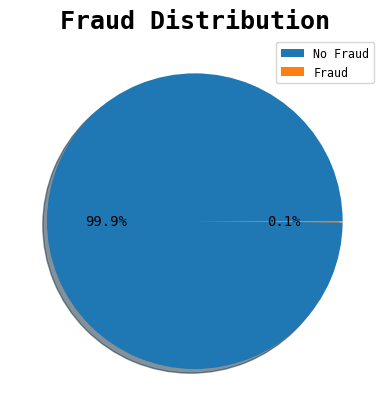

In [ ]:
isFraud_data = fe_df.isFraud.value_counts(normalize=True)
plt.pie(isFraud_data.values, shadow=True, autopct="%1.1f%%")
plt.title("Fraud Distribution")
plt.legend(["No Fraud", "Fraud"], fontsize="small")
plt.show()

### Data Quality Assessment

How many transactions are the same?

In [80]:
duplicate_transactions = fe_df.duplicated().sum()
rows, cols = fe_df.shape

print(f"Duplicated transactions as a % of total rows: {round((duplicate_transactions / rows) * 100, ndigits=5)}")

Duplicated transactions as a % of total rows: 0.00853


### Numerical Feature Analysis

Is amount normally distributed? Is it right skewed?

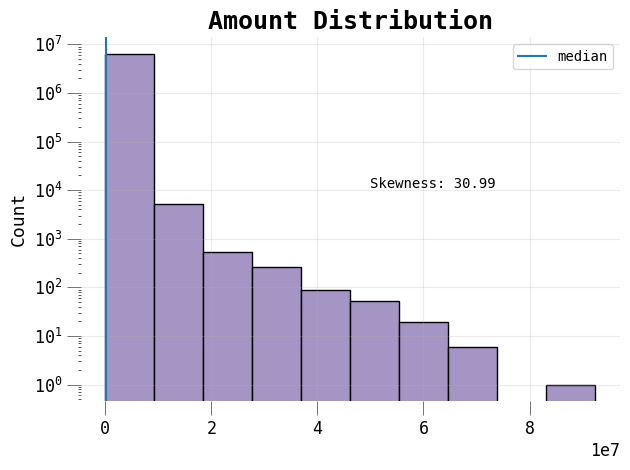

In [ ]:
amount_stats = fe_df.amount.agg(["median", "skew"])

plt.hist(fe_df.amount, color="#a495c4", log=True, edgecolor="black")
plt.axvline(amount_stats.iloc[0], label=f"median")
plt.text(50_000_000, 11_000, f"Skewness: {amount_stats.iloc[1]:.2f}")
plt.title("Amount Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.legend()
plt.show()

How many transactions are large? Are there many or most are normal transactions?

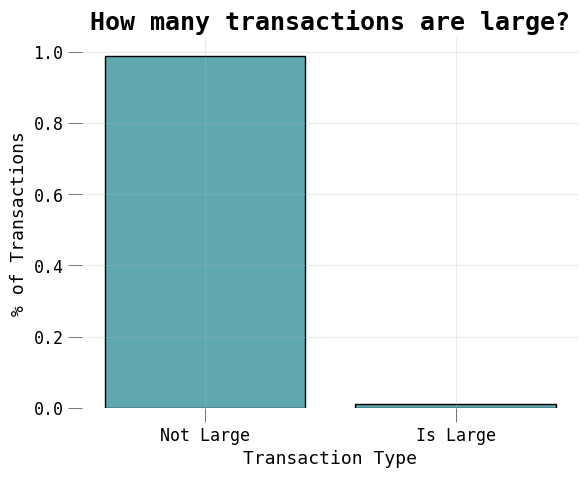

In [ ]:
large_transactions_counts = fe_df.isLargeTransaction.value_counts(normalize=True)

plt.bar(["Not Large", "Is Large"], large_transactions_counts.values, color="#60a8b0", edgecolor="black")
plt.xlabel("Transaction Type")
plt.ylabel("% of Transactions")
plt.title("How many transactions are large?")
plt.show()

How are balances distributed for both senders and receivers?

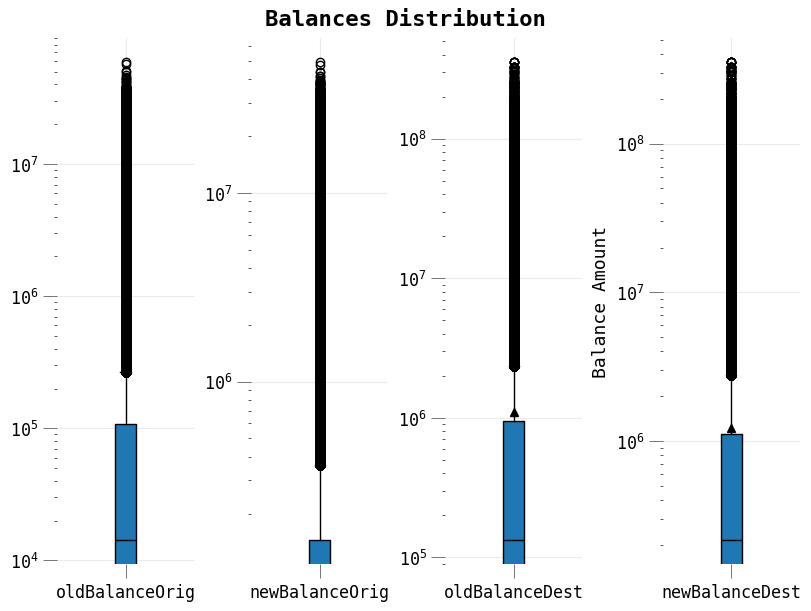

In [83]:
balance_types = ["oldBalanceOrig", "newBalanceOrig", "oldBalanceDest", "newBalanceDest"]

fig, axes = plt.subplots(nrows=1, ncols=4, constrained_layout=True, figsize=(8, 6))

for i in range(len(balance_types)):
    axes[i].boxplot(fe_df[balance_types[i]], patch_artist=True, showmeans=True, tick_labels=[balance_types[i]])
    axes[i].set_yscale("log")

plt.ylabel("Balance Amount")
plt.suptitle("Balances Distribution", fontsize=16, fontweight="bold")
plt.show()

### Categorical Feature Analysis

Are some transaction types more prevalent than others?

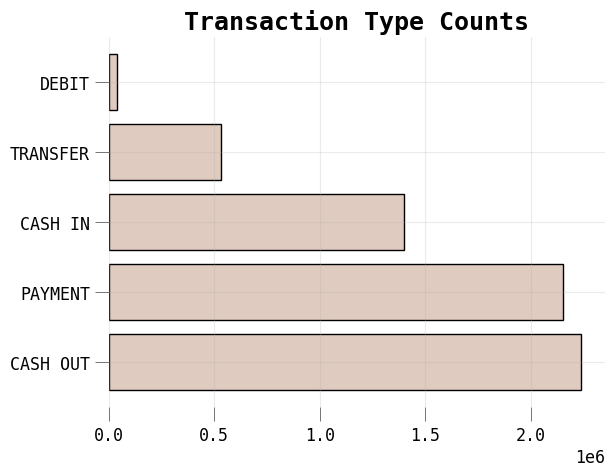

In [ ]:
transaction_type_counts = fe_df.type.value_counts()

plt.barh(transaction_type_counts.index, transaction_type_counts.values, edgecolor="black", color="#dfcbbf")
plt.title("Transaction Type Counts")
plt.show()

What is the average transaction amount per type?

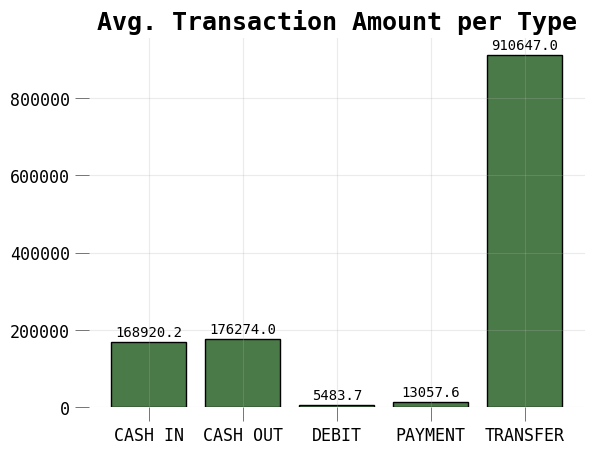

In [ ]:
avg_trans_amount_per_type = fe_df.groupby("type").amount.mean()

avg_amount_bar = plt.bar(avg_trans_amount_per_type.index, avg_trans_amount_per_type.values, edgecolor="black", color="#4a7a47")
plt.bar_label(avg_amount_bar, padding=2, fmt="%1.1f")
plt.title("Avg. Transaction Amount per Type")
plt.show()

### Feature vs. Target Analysis

Do some days of the week have higher fraud %?

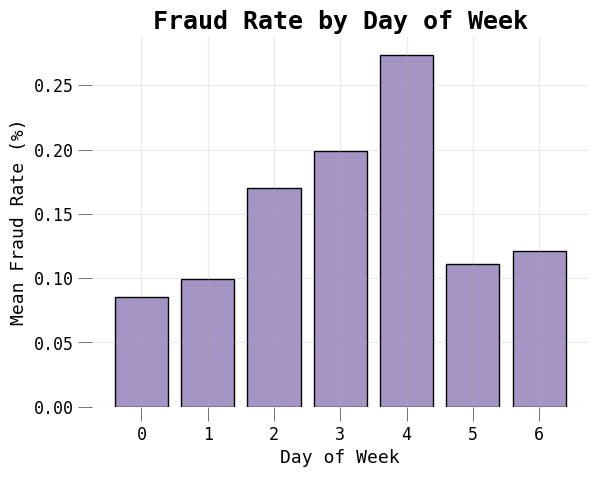

In [ ]:
days_of_week_fraud_df = (fe_df.groupby("dayOfWeek").isFraud.mean() * 100).to_frame()

plt.bar(days_of_week_fraud_df.index, days_of_week_fraud_df.values.flatten(), color="#a495c4", edgecolor="black")
plt.xlabel("Day of Week")
plt.ylabel("Mean Fraud Rate (%)")
plt.title("Fraud Rate by Day of Week")
plt.show()

Does transaction type tell us anything about frauds?

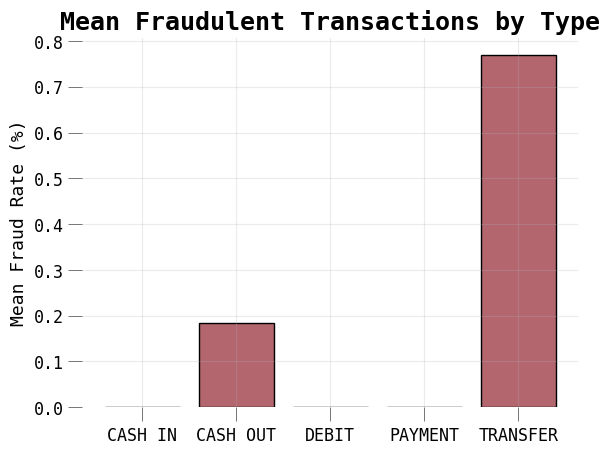

In [ ]:
mean_fraud_transaction_per_type = fe_df.groupby("type").isFraud.mean() * 100

plt.bar(mean_fraud_transaction_per_type.index, mean_fraud_transaction_per_type.values, edgecolor="black", color="#b4666f")
plt.title("Mean Fraudulent Transactions by Type")
plt.ylabel("Mean Fraud Rate (%)")
plt.show()

Are large transactions more fraudulent?

In [88]:
pd.crosstab(fe_df.isLargeTransaction, fe_df.isFraud, normalize="index")

isFraud,0,1
isLargeTransaction,,
0,0.999009,0.000991
1,0.969054,0.030946


### Correlation Analysis

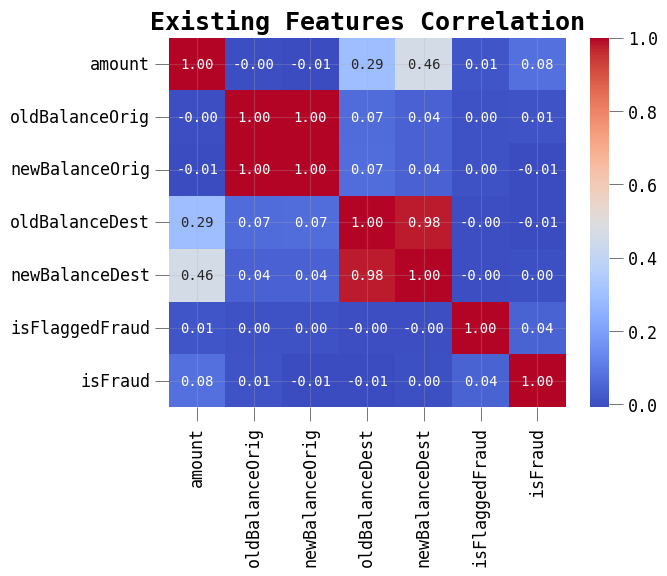

In [89]:
num_features = ["amount", "oldBalanceOrig", "newBalanceOrig", "oldBalanceDest", "newBalanceDest", "isFlaggedFraud", "isFraud"]
num_corrs = fe_df[num_features].corr(numeric_only=True)

sns.heatmap(num_corrs, annot=True, cmap="coolwarm", fmt="1.2f")
plt.title("Existing Features Correlation")
plt.show()

Are feature engineered columns more correlated compared to the pre-existing features?

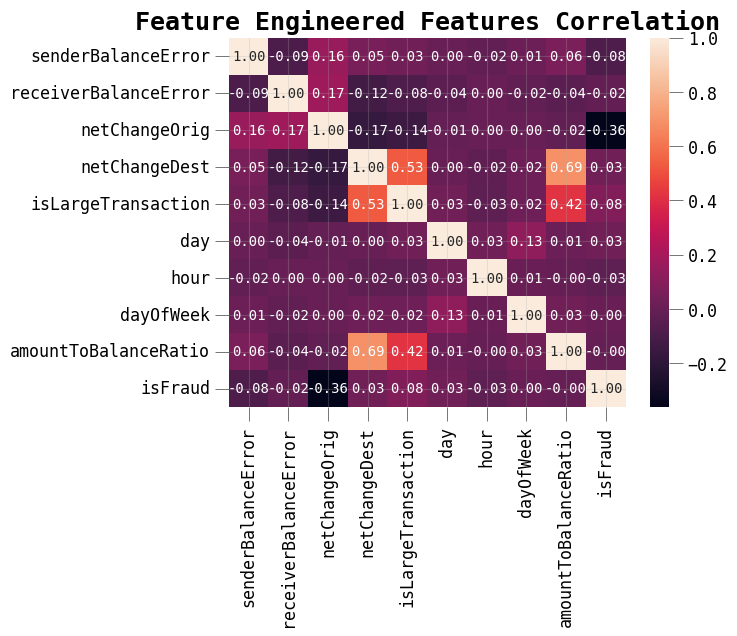

In [90]:
fe_num_features = ['senderBalanceError', 'receiverBalanceError', 'netChangeOrig',
       'netChangeDest', 'isLargeTransaction', 'day', 'hour', 'dayOfWeek',
       'amountToBalanceRatio', 'isFraud']
fe_num_corrs = fe_df[fe_num_features].corr()

sns.heatmap(fe_num_corrs, annot=True, fmt="1.2f")
plt.title("Feature Engineered Features Correlation")
plt.show()

### Outlier Analysis

Are many transaction amounts outliers? How many are above the 0.99 quantile?

In [91]:
amount_ninety_nine_q = stats.quantile(fe_df.amount, 0.99)
outlier_trans_amount_counts = fe_df[fe_df.amount > amount_ninety_nine_q].type.count()

print(f"Amount outliers (above 99th quantile): {(outlier_trans_amount_counts / rows):.2f}")

Amount outliers (above 99th quantile): 0.01


## Exploratory Data Analysis (EDA) Conclusions

1.	The target feature (“isFraud”) is heavily imbalanced with most transactions (99.9%) not fraudulent. In machine learning, the class will have to be balanced using weights.
2.	Numerical Feature Analysis:
-	Amount feature is right skewed, as evidenced by the high skewness value of 30.99. In fact, the dataset is made up of a few large transaction amounts, ranging in the many millions.
-	Despite the latter sentence, most transaction amounts aren’t large, represented by a value greater than the 99th quantile. According to the data, only 1% of transaction amounts are large.
-	Although substantial outliers exist, the majority of sender and receiver balances are concentrated well below the extreme values observed in the dataset.
3.	Categorical Feature Analysis:
-	The top transaction type is customer withdrawal, followed by merchant payment and customer deposit. Since the dataset is artificial, this may not represent real transaction types.
-	According to the data, transfers have the highest average transaction amount and not by a small margin. In fact, it reaches ≈911k compared to withdrawal at the second spot, at ≈176k.
4.	Feature vs. Target Analysis:
-	Weekday 4 has the highest average fraud rate, at ≈0.27%, followed by day 3 (0.2) and 2 (0.17). Since we don’t know which day is which, it is hard to draw meaningful conclusions.
-	Fraud is heavily concentrated in transfer transactions, with a fraud rate substantially higher than all other transaction categories. Withdrawals show the second-highest fraud rate, while the remaining transaction types exhibit very little fraudulent activity.
5.	Correlation Analysis:
-	Dataset features don’t seem to be highly correlated with the target, with most correlations being close to 0.
6.	Outlier Analysis:
-	Large transaction amounts (above the 99th quantile) represent only 1%. 

Most transactions remain the usual range, in the many hundreds of thousands or a few millions.
Although PaySim is a simulated dataset and therefore may not fully capture real-world financial behavior, it provides a useful environment for studying fraud-detection workflows, feature engineering, class imbalance and supervised machine-learning techniques.